# Homework 4

## Juhi Malwade

## Linear Regression with Gradient Descent

Your task in this assignment is to implement Multiple Linear Regression. 

We will use the New York City Taxi trip reports in the Year 2013. 
The dataset was released under the FOIL (The Freedom of Information Law) and made public by Chris Whong (\url{https://chriswhong.com/open-data/foil_nyc_taxi/}).



# Taxi Data Set
The data set itself is a simple text file. Each taxi trip report is a different line in the file. Among other things, each trip report 
includes the starting point, the drop-off point, corresponding timestamps, and information related to the payment. The data are reported 
by the time that the trip ended, i.e., upon arriving in the order of the drop-off timestamps. 
The attributes present on each line of the file are, in order:



| index | **Attribute** | **Description** |
| --- | --- | --- |
| 0 | medallion           |  an md5sum of the identifier of the taxi - vehicle bound (Taxi ID)  | 
| 1 | hack license       |  an md5sum of the identifier for the taxi license (Driver ID)  |  
| 2 | pickup datetime    | time when the passenger(s) were picked up  |  
| 3 | dropoff datetime   | time when the passenger(s) were dropped off  | 
| 4 | trip time in secs | duration of the trip  |  
| 5 | trip distance | trip distance in miles  |  
| 6 | pickup longitude | longitude coordinate of the pickup location  |  
| 7 | pickup latitude | latitude coordinate of the pickup location  |  
| 8 | dropoff longitude | longitude coordinate of the drop-off location   |  
| 9 | dropoff latitude | latitude coordinate of the drop-off location  | 
| 10 | payment type | the payment method -credit card or cash  |  
| 11 | fare amount | fare amount in dollars  |  
| 12 | surcharge | surcharge in dollars  |  
| 13 | mta tax | tax in dollars  |  
| 14 | tip amount | tip in dollars  |  
| 15 | tolls amount | bridge and tunnel tolls in dollars  |  
| 16 | total amount | total paid amount in dollars  |  




The data files are in comma separated values (CSV) format. Example lines from the file are:

07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,\\
2013-01-01,00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,\\
40.715008,CSH,3.50,0.50,0.50,0.00,0.00,4.50

22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,\\
2013-01-01,00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,\\
CSH,27.00,0.00,0.50,0.00,0.00,27.50

0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,\\
2013-01-01,00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897\\
73.965897,40.760445,CSH,4.00,0.50,0.50,0.00,0.00,5.00



In [105]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

In [106]:
df = pd.read_csv('nyc-taxi-data.csv')
df.head()

,07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,2013-01-01 00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,40.715008,CSH,3.50,0.50,0.50.1,0.00,0.00.1,4.50
0,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.00,0.0,27.50
1,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
2,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
4,5FAA7F69213D26A42FA435CA9511A4FF,00B7691D86D96AEBD21DD9E138F90840,2013-01-01 00:02:00,2013-01-01 00:03:00,60,0.00,0.000000,0.000000,0.000000,0.000000,CRD,2.5,0.5,0.5,0.25,0.0,3.75


## Task - 1
The dataset is a real-world dataset and many records are incorrect and wrong. Your task is first to describe at least 4 data clean up tasks and implement them on this data set.

For example, you can define to remove lines with the following property, if a taxi trip (one of the data rows) has a travel distance less than 1 mile and total amount of more than 20 dollar, then it is an wrong record. 

Another example is that you would expect to have a float number (e.g., index 12 to 16) and then you got a String in that position. You can remove such lines from your data. 

Perform the following cleanup tasks:
1. Add column headers based on the description above (no need to describe).
2. Drop rows with a travel distance < 1 mile and a total fare > $20 (no need to describe). Both conditions need to be met.
3. Drop rows where pickup or dropoff lat is less than 35 or pickup or dropoff long is greater than -65
4. Drop rows with UNK payment type

**(4 points)**

In [107]:
# Add column headers based on the description above
df.columns = ["medallion", "hack_license", "pickup_datetime", "dropoff_datetime", "trip_time", "trip_dist", "pickup_long", "pickup_lat", "dropoff_long", "dropoff_lat", "payment_type", "fare", "surcharge", "mta_tax", "tip_amount", "tolls_amount", "total_amount"]
df.head()

,medallion,hack_license,pickup_datetime,dropoff_datetime,trip_time,trip_dist,pickup_long,pickup_lat,dropoff_long,dropoff_lat,payment_type,fare,surcharge,mta_tax,tip_amount,tolls_amount,total_amount
0,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.00,0.0,27.50
1,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
2,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
4,5FAA7F69213D26A42FA435CA9511A4FF,00B7691D86D96AEBD21DD9E138F90840,2013-01-01 00:02:00,2013-01-01 00:03:00,60,0.00,0.000000,0.000000,0.000000,0.000000,CRD,2.5,0.5,0.5,0.25,0.0,3.75


In [108]:
# Drop rows with a travel distance <1 mile and a total fare > $20
df = df[(df['trip_dist'] >= 1) & (df['total_amount'] <= 20)]

In [109]:
# Drop rows where pickup lat is less than 35 and pickup long is greater than -65
df = df[(df['pickup_long'] < -65) & (df['pickup_lat'] > 35)]
print("Pickup lat min and max:", df['pickup_lat'].min(), df['pickup_lat'].max())
print("Pickup long min and max:", df['pickup_long'].min(), df['pickup_long'].max(), "\n")

# Drop rows where dropoff lat is less than 35 and dropoff long is greater than -65
df = df[(df['dropoff_long'] < -65) & (df['dropoff_lat'] > 35)]
print("Dropoff lat min and max:", df['dropoff_lat'].min(), df['dropoff_lat'].max())
print("Dropoff long min and max:", df['dropoff_long'].min(), df['dropoff_long'].max())

Pickup lat min and max: 40.564217 43.016666
Pickup long min and max: -74.23259 -71.300003 

Dropoff lat min and max: 40.570034 49.549999
Dropoff long min and max: -78.316666 -71.300003


In [110]:
# Drop rows where payment type is unknown
print("Before:", df['payment_type'].value_counts(), "\n")

df = df[df['payment_type'] != "UNK"]

print("After:", df['payment_type'].value_counts())

Before: payment_type
CSH    18691
CRD    12312
UNK        8
Name: count, dtype: int64 

After: payment_type
CSH    18691
CRD    12312
Name: count, dtype: int64


## Task - 2
Use the cleaned dataset from task 1.
Find out the correlations between trip distance, travel time and fare amount. Visualize the correlations in form of Scatterplot matrix. 
Describe the correlations between them. **(4 points)**

#### Description

The correlation between trip distance and fare amount is the greatest, with a correlation coefficient of 0.872, indicating there is a strong positive linear correlation between trip distance and fare amount. 

The correlation between trip time and fare amount is the second greatest, with a correlation coefficient of 0.828. This indicates there is also a strong positive linear correlation between trip time and fare amount.

The correlation between trip time and trip distance is the smallest among the three correlations. It has a correlation coefficient of 0.643, indicating there is a somewhat strong positive linear correlation between trip time and trip distance.

              trip_dist  trip_time  total_amount
trip_dist      1.000000   0.642988      0.872076
trip_time      0.642988   1.000000      0.827880
total_amount   0.872076   0.827880      1.000000


array([[<Axes: xlabel='trip_dist', ylabel='trip_dist'>,
        <Axes: xlabel='trip_time', ylabel='trip_dist'>,
        <Axes: xlabel='total_amount', ylabel='trip_dist'>],
       [<Axes: xlabel='trip_dist', ylabel='trip_time'>,
        <Axes: xlabel='trip_time', ylabel='trip_time'>,
        <Axes: xlabel='total_amount', ylabel='trip_time'>],
       [<Axes: xlabel='trip_dist', ylabel='total_amount'>,
        <Axes: xlabel='trip_time', ylabel='total_amount'>,
        <Axes: xlabel='total_amount', ylabel='total_amount'>]],
      dtype=object)

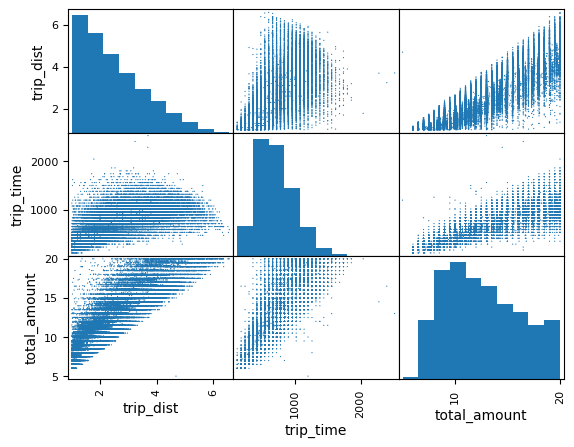

In [111]:
# Note: I am assuming fare amount refers to the total amount paid, not the fare amount

print(df[['trip_dist', 'trip_time', 'total_amount']].corr())

scatter_matrix(df[['trip_dist', 'trip_time', 'total_amount']], alpha = 1, s = 3)

## Task - 3
Use the cleaned dataset from task 1.
We want to find a simple line to our data (distance, money). 
We want to use trip distance, and fare amount. Use the **Scikit-learn** library to fit a line into the data. **(2 points)**

* Provide the Regression Cofficients of your model
* Write down your linear regression equation. 
* Use your model to predict the fare amount for a 3 miles trip. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [112]:
# Build the model

X = df[["trip_dist"]]
y = df[["total_amount"]]

linModel = LinearRegression()
linModel.fit(X, y)

print("Estimated weight for distance feature: ", linModel.coef_)
print("Estimated intercept for fare amount: ", linModel.intercept_)

print(
    "Predicted Total Amount = ",
    linModel.intercept_[0],
    " + ",
    linModel.coef_[0][0],
    "* (Trip Distance)"
)

Estimated weight for distance feature:  [[2.83598197]]
Estimated intercept for fare amount:  [5.45944221]
Predicted Total Amount =  5.459442205353801  +  2.835981969546384 * (Trip Distance)


The regression coefficients are 2.84, which is the slope, and 5.46, which is the y intercept

The linear regression equation is:
Fare amount = 2.84 * trip distance + 5.46

Equivalently, this is: y = 2.84x + 5.46

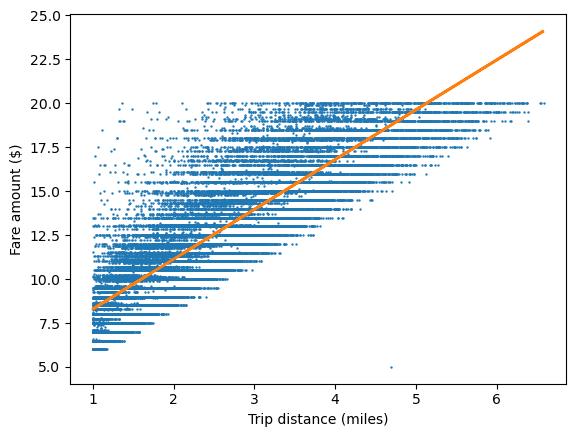

In [113]:
# Create graph - code from Zybook

yPred = linModel.predict(X)

plt.scatter(X, y, color="#1f77b4", s = 0.5)
plt.plot(X, yPred, color="#ff7f0e", linewidth=2)
plt.xlabel("Trip distance (miles)")
plt.ylabel("Fare amount ($)")
plt.show()

In [114]:
# Predict fare amount for 3 mile trip
linModel.predict([[3]])

/Users/juhimalwade/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[13.96738811]])

The predicted fare amount for a 3 mile trip is $13.97.

## Task - 4
Fit a Multiple Linear Regression hyperplane into this data. We are interested to predict total amount out of trip distance, tavel time. **(4 points)**
Use the **Scikit-learn** library.

* Provide the Regression Cofficients of your model
* Write down your Multiple Linear Regression equation. 
* Use your model to predict the total amount for a 3 miles trip and 6 min travel time. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [115]:
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits import mplot3d

In [116]:
# Building the model - code from zybook

X = df[["trip_dist", "trip_time"]].values.reshape(-1, 2)
y = df[["total_amount"]].values.reshape(-1, 1)

linModel = LinearRegression()
linModel.fit(X, y)

print(
    "Predicted Total Amount = ",
    linModel.intercept_[0],
    " + ",
    linModel.coef_[0][0],
    "* (Trip Distance)",
    " + ",
    linModel.coef_[0][1],
    "* (Trip Time)",
)

Predicted Total Amount =  3.811504738466409  +  1.8836601006485485 * (Trip Distance)  +  0.005898597481298356 * (Trip Time)


The coefficients are:

- 3.812 - the intercept

- 1.884 - estimated weight for distance feature

- 0.006 - estimated weight for trip time


The multiple linear regression equation is:

- Predicted Total Amount =  3.812  +  1.884 * (Trip Distance)  +  0.006 * (Trip Time)

In [117]:
# Predict fare amount for 3 mile + 6 minute trip

linModel.predict([[3, 360]])

array([[11.58598013]])

The predicted fare amount for a 3 mile + 6 minute trip is $11.59.

## Task - 5 - Gradient Descent
Implement the gradient descent optimization to find the optimal parameters for our Simple Linear Regression model of task 3. **(6 points)**

* Define and set your learning rate (start with a very small number and increase it if your GC works)
* Instantiate all coefficients from zero
* Run maximum 400 interations. You can stop if your cost converge with a precision of 0.01 
* Print and visualize the optimization costs
* Provide the Regression Coefficients of your model after stop or convergance. 

Please note that a visualization **is** required, unlike in Task 3 and 4.

Number of iterations:  84
Minimum cost:  4.7666394300930355
Weight (w) =  3.9053499166077814
Bias (b) =  2.356137175354885
Total Amount = 2.356137175354885 + 3.9053499166077814 * (Trip Distance)


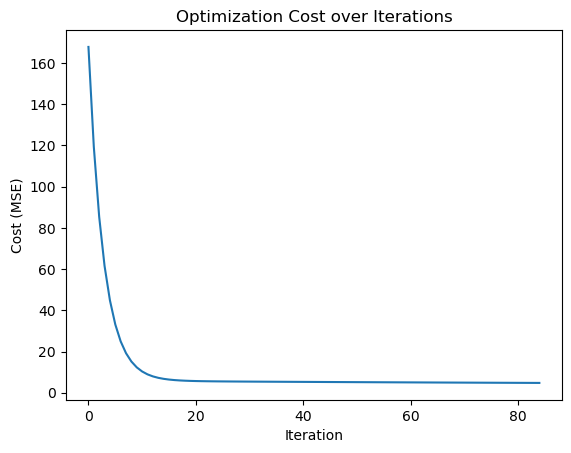

In [120]:
X = df["trip_dist"]
y = df["total_amount"]
n = len(y)

w = 0.0
b = 0.0
learning_rate = 0.01
precision = 0.01

costs = []
weights = []

for i in range(400):
    y_pred = w * X + b

    cost = (1/n) * np.sum((y_pred - y)**2)
    costs.append(cost)

    if i > 0 and abs(costs[-2] - costs[-1]) < precision:
        print("Number of iterations: ", i)
        break

    dw = (2/n) * np.sum(X * (y_pred - y))
    db = (2/n) * np.sum(y_pred - y)

    w = w - (learning_rate * dw)
    b = b - (learning_rate * db)

print("Minimum cost: ", min(costs))
print("Weight (w) = ", w)
print("Bias (b) = ", b)
print(f"Total Amount = {b} + {w} * (Trip Distance)")

plt.plot(range(len(costs)), costs)
plt.title("Optimization Cost over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.show()